#  Electronics Pricing Analysis

 data exploration, data-quality checks, cleaning, normalization, wrangling, exploratory analysis, outlier and correlation checks, and stakeholder-facing visualizations.

  
**Source:** `project/electronics_pricing_clean.csv`

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Business questions

1. Does actual brand pricing match the intended market position?
2. Which brands and merchants depend most on discounts?
3. Where are the strongest channel-coverage opportunities and risks?
4. Which categories offer less noisy competitive space?
5. What value do used and refurbished products offer relative to new products?

In [62]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
get_ipython().run_line_magic("matplotlib", "inline")
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)



In [63]:
DATA_PATH = Path("/content/drive/MyDrive/project/electronics_pricing_clean.csv")

df = pd.read_csv(DATA_PATH)

df["date_seen"] = pd.to_datetime(df["date_seen_clean"], utc=True, errors="coerce")
df["sale_flag"] = df["prices.isSale"].astype(str).str.lower().map({"true": True, "false": False}).fillna(False)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns from {DATA_PATH}")

Loaded 7,235 rows and 35 columns from /content/drive/MyDrive/project/electronics_pricing_clean.csv


# Part 00 — Exploring The Dataset

## Data overview

In [64]:
display(df.head())
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "non_null": df.notna().sum(), "unique": df.nunique(dropna=True)}))

,id,prices.amountMax,prices.amountMin,prices.availability,prices.condition,prices.currency,prices.dateSeen,prices.isSale,prices.merchant,prices.shipping,prices.sourceURLs,asins,brand,categories,dateAdded,dateUpdated,imageURLs,keys,manufacturerNumber,name,primaryCategories,sourceURLs,upc,weight,condition_clean,availability_clean,brand_clean,merchant_clean,shipping_clean,shipping_type,date_seen_clean,price,category_clean,date_seen,sale_flag
0,AVphzgbJLJeJML43fA0o,104.99,104.99,Yes,New,USD,"2017-03-30T06:00:00Z,2017-03-10T22:00:00Z,2017...",False,Bestbuy.com,NaN,http://www.bestbuy.com/site/sanus-tv-wall-moun...,B00C78VIUE,Sanus,"Audio & Video Accessories,TV Mounts,TV Accesso...",2015-04-13T12:00:51Z,2018-05-12T18:59:48Z,https://images-na.ssl-images-amazon.com/images...,sanusvlf410b110inchsuperslimfullmotionmountfor...,VLF410B1,Sanus VLF410B1 10-Inch Super Slim Full-Motion ...,Electronics,https://www.amazon.com/Sanus-VLF410B1-10-Inch-...,7.94E+11,32.8 pounds,new,available,Sanus,bestbuy.com,NaN,unknown,2017-03-30 06:00:00+00:00,104.990,TV & Home Theater,2017-03-30 06:00:00+00:00,False
1,AVpgMuGwLJeJML43KY_c,69.00,64.99,In Stock,New,USD,2017-12-14T06:00:00Z,True,Walmart.com,Expedited,https://www.walmart.com/ip/BOYTONE-BT210FB-BLA...,"B018K251JE,B00VILQKQ8",Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18T14:14:56Z,2018-06-13T19:39:02Z,https://images-na.ssl-images-amazon.com/images...,boytone2500w21chhometheatersystemblackdiamond/...,BT-210F,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Electronics,http://reviews.bestbuy.com/3545/4784804/review...,6.42E+11,14 pounds,new,available,Boytone,walmart.com,expedited,paid/other,2017-12-14 06:00:00+00:00,66.995,TV & Home Theater,2017-12-14 06:00:00+00:00,True
2,AVpgMuGwLJeJML43KY_c,69.00,69.00,In Stock,New,USD,2017-09-08T05:00:00Z,False,Walmart.com,Expedited,https://www.walmart.com/ip/Boytone-BT-210F-Blu...,"B018K251JE,B00VILQKQ8",Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18T14:14:56Z,2018-06-13T19:39:02Z,https://images-na.ssl-images-amazon.com/images...,boytone2500w21chhometheatersystemblackdiamond/...,BT-210F,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Electronics,http://reviews.bestbuy.com/3545/4784804/review...,6.42E+11,14 pounds,new,available,Boytone,walmart.com,expedited,paid/other,2017-09-08 05:00:00+00:00,69.000,TV & Home Theater,2017-09-08 05:00:00+00:00,False
3,AVpgMuGwLJeJML43KY_c,69.99,69.99,Yes,New,USD,2017-10-10T05:00:00Z,False,Bestbuy.com,NaN,https://www.bestbuy.com/site/boytone-2500w-2-1...,"B018K251JE,B00VILQKQ8",Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18T14:14:56Z,2018-06-13T19:39:02Z,https://images-na.ssl-images-amazon.com/images...,boytone2500w21chhometheatersystemblackdiamond/...,BT-210F,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Electronics,http://reviews.bestbuy.com/3545/4784804/review...,6.42E+11,14 pounds,new,available,Boytone,bestbuy.com,NaN,unknown,2017-10-10 05:00:00+00:00,69.990,TV & Home Theater,2017-10-10 05:00:00+00:00,False
4,AVpgMuGwLJeJML43KY_c,66.99,66.99,Yes,New,USD,2017-08-28T07:00:00Z,False,Bestbuy.com,NaN,https://www.bestbuy.com/site/boytone-2500w-2-1...,"B018K251JE,B00VILQKQ8",Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18T14:14:56Z,2018-06-13T19:39:02Z,https://images-na.ssl-images-amazon.com/images...,boytone2500w21chhometheatersystemblackdiamond/...,BT-210F,Boytone - 2500W 2.1-Ch. Home Theater System - ...,Electronics,http://reviews.bestbuy.com/3545/4784804/review...,6.42E+11,14 pounds,new,available,Boytone,bestbuy.com,NaN,unknown,2017-08-28 07:00:00+00:00,66.990,TV & Home Theater,2017-08-28 07:00:00+00:00,False


,dtype,non_null,unique
id,object,7235,835
prices.amountMax,float64,7235,2515
prices.amountMin,float64,7235,2664
prices.availability,object,7235,14
prices.condition,object,7235,11
prices.currency,object,7235,1
prices.dateSeen,object,7235,3828
prices.isSale,bool,7235,2
prices.merchant,object,7235,692
prices.shipping,object,4273,73


## Coverage and grain

In [65]:
summary = pd.Series({"rows": len(df), "products": df["id"].nunique(), "brands": df["brand_clean"].nunique(), "merchants": df["merchant_clean"].nunique(), "categories": df["category_clean"].nunique(), "earliest_seen": df["date_seen"].min(), "latest_seen": df["date_seen"].max()})
display(summary.to_frame("value"))

,value
rows,7235
products,835
brands,238
merchants,680
categories,7
earliest_seen,2014-08-30 16:00:00+00:00
latest_seen,2018-07-25 23:00:00+00:00


## Checks

In [66]:
assert df["id"].notna().all()
assert df["price"].notna().mean() > .95
print("Core input checks passed.")

Core input checks passed.


# Part 01 — Handling Duplicates

## Duplicate diagnostics

In [67]:
exact = df.duplicated(keep=False)
business_key = ["id", "merchant_clean", "date_seen", "price", "sale_flag"]
key_dupes = df.duplicated(business_key, keep=False)
print("Exact duplicate rows:", int(exact.sum()))
print("Rows duplicated on analytical key:", int(key_dupes.sum()))
display(df.loc[key_dupes, business_key].sort_values(business_key).head(20))

Exact duplicate rows: 0
Rows duplicated on analytical key: 11


,id,merchant_clean,date_seen,price,sale_flag
1664,AVpg9lcJ1cnluZ0-8h3k,bestbuy.com,2018-05-26 07:00:00+00:00,4295.98,False
1665,AVpg9lcJ1cnluZ0-8h3k,bestbuy.com,2018-05-26 07:00:00+00:00,4295.98,False
1961,AVqVGTt2v8e3D1O-ldE7,bestbuy.com,2018-05-26 07:00:00+00:00,2799.99,False
1963,AVqVGTt2v8e3D1O-ldE7,bestbuy.com,2018-05-26 07:00:00+00:00,2799.99,False
1965,AVqVGTt2v8e3D1O-ldE7,bestbuy.com,2018-05-26 07:00:00+00:00,2799.99,False
2695,AVqkEzW9U2_QcyX9O0Gr,bestbuy.com,2017-09-18 09:00:00+00:00,149.99,False
2696,AVqkEzW9U2_QcyX9O0Gr,bestbuy.com,2017-09-18 09:00:00+00:00,149.99,False
2714,AVqkEzW9U2_QcyX9O0Gr,bestbuy.com,2017-10-10 14:00:00+00:00,139.99,False
2716,AVqkEzW9U2_QcyX9O0Gr,bestbuy.com,2017-10-10 14:00:00+00:00,139.99,False
4489,AVwjc_-jv8e3D1O-nnKy,bestbuy.com,2017-10-10 22:00:00+00:00,449.99,False


## Deduplicate conservatively

In [68]:
df_dedup = df.drop_duplicates().copy()
print(f"{len(df):,} -> {len(df_dedup):,} rows")
assert not df_dedup.duplicated().any()

7,235 -> 7,235 rows


## Takeaway

Only exact row duplicates are removed. Repeated products across merchants or dates remain because they are valid listing observations.

# Part 02 — Handling Missing Values

In [69]:
kpi_cols = ["id","brand_clean","merchant_clean","category_clean","price","sale_flag","date_seen","condition_clean","shipping_type"]
missing = df[kpi_cols].isna().agg(["sum","mean"]).T
missing["mean"] *= 100
missing.columns = ["missing_rows","missing_pct"]
display(missing.sort_values("missing_pct", ascending=False))

,missing_rows,missing_pct
id,0.0,0.0
brand_clean,0.0,0.0
merchant_clean,0.0,0.0
category_clean,0.0,0.0
price,0.0,0.0
sale_flag,0.0,0.0
date_seen,0.0,0.0
condition_clean,0.0,0.0
shipping_type,0.0,0.0


## Analytical treatment

In [70]:
analysis_df = df.copy()
for col in ["brand_clean","merchant_clean","category_clean","condition_clean","shipping_type"]:
    analysis_df[col] = analysis_df[col].fillna("unknown")
analysis_df = analysis_df.dropna(subset=["id","price"])
print(f"Analysis-ready rows: {len(analysis_df):,}")

Analysis-ready rows: 7,235


## Checks

In [71]:
assert analysis_df[["id","price"]].notna().all().all()
print("Required identifiers and prices are complete.")

Required identifiers and prices are complete.


# Part 03 — Normalizing Data

## Standardize fields

In [72]:
normalized = df.copy()
for col in ["brand_clean","merchant_clean","category_clean","condition_clean","availability_clean","shipping_type"]:
    normalized[col] = normalized[col].astype("string").str.strip()
normalized["condition_clean"] = normalized["condition_clean"].str.lower().replace({"pre-owned":"used"})
normalized["year"] = normalized["date_seen"].dt.year
normalized["month"] = normalized["date_seen"].dt.to_period("M").astype(str)
normalized["midpoint_price"] = normalized[["prices.amountMin","prices.amountMax"]].mean(axis=1)
display(normalized[["brand_clean","merchant_clean","category_clean","condition_clean","year","month","midpoint_price"]].head())

,brand_clean,merchant_clean,category_clean,condition_clean,year,month,midpoint_price
0,Sanus,bestbuy.com,TV & Home Theater,new,2017,2017-03,104.990
1,Boytone,walmart.com,TV & Home Theater,new,2017,2017-12,66.995
2,Boytone,walmart.com,TV & Home Theater,new,2017,2017-09,69.000
3,Boytone,bestbuy.com,TV & Home Theater,new,2017,2017-10,69.990
4,Boytone,bestbuy.com,TV & Home Theater,new,2017,2017-08,66.990


## Validation

In [73]:
assert normalized["condition_clean"].dropna().str.strip().eq(normalized["condition_clean"].dropna()).all()
assert normalized["midpoint_price"].ge(0).all()
print("Normalization checks passed.")

Normalization checks passed.


# Part 04 — Data Wrangling

## Build analysis table

In [74]:
analysis = df.drop_duplicates().copy()
analysis["month"] = analysis["date_seen"].dt.to_period("M").astype(str)
analysis["price_midpoint"] = analysis[["prices.amountMin","prices.amountMax"]].mean(axis=1)
analysis["is_free_shipping"] = analysis["shipping_type"].eq("free")
analysis = analysis.dropna(subset=["id","brand_clean","merchant_clean","category_clean","price_midpoint"])
print(analysis.shape)

(7235, 38)


## Brand/category pricing KPIs

In [75]:
category_avg = analysis.groupby("category_clean")["price_midpoint"].mean().rename("category_avg_price")
brand_category = analysis.groupby(["category_clean","brand_clean"]).agg(avg_price=("price_midpoint","mean"), listings=("id","size")).reset_index().join(category_avg, on="category_clean")
brand_category["price_index"] = 100 * brand_category["avg_price"] / brand_category["category_avg_price"]
brand_category["price_percentile"] = brand_category.groupby("category_clean")["avg_price"].rank(pct=True)
brand_category["price_tier"] = pd.cut(brand_category["price_percentile"], [0,.25,.75,1], labels=["bottom 25%","middle 50%","top 25%"], include_lowest=True)
display(brand_category.sort_values("listings", ascending=False).head(15))

,category_clean,brand_clean,avg_price,listings,category_avg_price,price_index,price_percentile,price_tier
298,TV & Home Theater,Samsung,1418.723481,451,937.817075,151.279340,0.947368,top 25%
306,TV & Home Theater,Sony,1244.643193,332,937.817075,132.717054,0.929825,top 25%
103,Cameras & Photography,Sony,727.658700,223,401.864915,181.070472,0.972973,top 25%
127,Computers & Tablets,Corsair,156.067108,185,421.749839,37.004663,0.552941,middle 50%
248,Mobile & Phones,Sony,165.419973,184,189.215978,87.423892,0.718750,middle 50%
115,Computers & Tablets,Apple,1529.708659,164,421.749839,362.705215,0.976471,top 25%
282,TV & Home Theater,Lg,2060.608750,160,937.817075,219.723953,0.982456,top 25%
315,TV & Home Theater,Yamaha,518.573984,128,937.817075,55.295857,0.771930,top 25%
165,Computers & Tablets,Samsung,277.411008,124,421.749839,65.776198,0.705882,middle 50%
117,Computers & Tablets,Asus,552.595752,113,421.749839,131.024532,0.870588,top 25%


## Checks

In [76]:
assert analysis["price_midpoint"].notna().all()
assert brand_category["price_index"].gt(0).all()
print("KPI tables are ready.")

KPI tables are ready.


# Part 05 — Exploratory Data Analysis

## Core KPI tables

In [77]:
brand_kpis = df.groupby("brand_clean").agg(avg_price=("price","mean"), discount_rate=("sale_flag","mean"), channel_coverage=("merchant_clean","nunique"), listings=("id","size"), free_shipping_rate=("shipping_type", lambda s: s.eq("free").mean())).query("listings >= 10").sort_values("listings", ascending=False)
brand_kpis[["discount_rate","free_shipping_rate"]] *= 100
display(brand_kpis.head(20).round(2))

,avg_price,discount_rate,channel_coverage,listings,free_shipping_rate
brand_clean,,,,,
Sony,822.70,32.23,96,785,23.06
Samsung,982.32,39.84,74,743,18.84
Apple,1094.88,28.40,27,243,7.00
Yamaha,398.18,28.75,19,240,6.67
Corsair,152.53,13.33,33,195,6.67
Pioneer,279.69,32.39,42,176,11.36
Lg,1887.47,42.86,31,175,25.71
Sandisk,140.41,28.26,19,138,2.17
Logitech,116.80,11.21,35,116,21.55


## Competition by category

In [78]:
competition = df.groupby("category_clean").agg(brand_count=("brand_clean","nunique"), listing_count=("id","size"), product_count=("id","nunique"))
competition["competition_score"] = competition["brand_count"] / competition["listing_count"]
display(competition.sort_values(["brand_count","listing_count"]).round(4))

,brand_count,listing_count,product_count,competition_score
category_clean,,,,
Other Electronics,1,2,1,0.5000
Audio,36,299,58,0.1204
Automotive Electronics,37,796,92,0.0465
Cameras & Photography,37,881,87,0.0420
TV & Home Theater,57,1913,204,0.0298
Mobile & Phones,64,1145,157,0.0559
Computers & Tablets,85,2199,236,0.0387


## Condition value

In [79]:
condition_price = df.groupby("condition_clean").agg(avg_price=("price","mean"), listings=("id","size")).sort_values("listings", ascending=False)
display(condition_price.round(2))

,avg_price,listings
condition_clean,,
new,487.38,7005
used,314.41,146
refurbished,211.68,83
other,70.68,1


# Part 06 — Finding How Data Distributes

## Numeric distribution

In [80]:
display(df["price"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).to_frame())

,price
count,7235.000000
mean,480.667191
std,717.099922
min,6.450000
1%,18.257200
5%,31.997000
25%,79.990000
50%,196.765000
75%,488.745000
95%,2109.590000


## Categorical distributions

In [81]:
for col in ["brand_clean","merchant_clean","category_clean","condition_clean","availability_clean"]:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).head(15).to_frame("rows"))


brand_clean


,rows
brand_clean,
Sony,785
Samsung,743
Apple,243
Yamaha,240
Corsair,195
Pioneer,176
Lg,175
Sandisk,138
Logitech,116



merchant_clean


,rows
merchant_clean,
bestbuy.com,2794
bhphotovideo.com,1509
walmart.com,663
beach camera,201
ami ventures inc,63
buydig,53
focus camera,48
gear4less,43
echo-and-optics,40



category_clean


,rows
category_clean,
Computers & Tablets,2199
TV & Home Theater,1913
Mobile & Phones,1145
Cameras & Photography,881
Automotive Electronics,796
Audio,299
Other Electronics,2



condition_clean


,rows
condition_clean,
new,7005
used,146
refurbished,83
other,1



availability_clean


,rows
availability_clean,
available,6852
limited/pending,200
unavailable,143
unknown,40


# Part 07 — Finding Outliers

## Category-aware IQR flags

In [82]:
q = df.groupby("category_clean")["price"].quantile([.25,.75]).unstack()
q.columns = ["q1","q3"]
q["iqr"] = q["q3"] - q["q1"]
flagged = df.join(q, on="category_clean")
flagged["price_outlier"] = (flagged["price"] < flagged["q1"] - 1.5*flagged["iqr"]) | (flagged["price"] > flagged["q3"] + 1.5*flagged["iqr"])
print(f"Outliers: {flagged.price_outlier.sum():,} ({flagged.price_outlier.mean():.1%})")
display(flagged.loc[flagged.price_outlier, ["name","brand_clean","category_clean","price","q1","q3"]].sort_values("price", ascending=False).head(20))

Outliers: 623 (8.6%)


,name,brand_clean,category_clean,price,q1,q3
5888,Samsung - 65 Class - LED - MU6290 Series - 216...,Samsung,TV & Home Theater,6498.990,234.99,1399.9900
5878,Samsung - 65 Class - LED - MU6290 Series - 216...,Samsung,TV & Home Theater,5999.990,234.99,1399.9900
2283,Sony - 55 Class - OLED - A1E Series - 2160p - ...,Sony,TV & Home Theater,4999.990,234.99,1399.9900
3629,XBR-X850E-Series 75-Class HDR UHD Smart LED TV,Sony,TV & Home Theater,4999.990,234.99,1399.9900
2284,Sony - 55 Class - OLED - A1E Series - 2160p - ...,Sony,TV & Home Theater,4647.995,234.99,1399.9900
2287,Sony - 55 Class - OLED - A1E Series - 2160p - ...,Sony,TV & Home Theater,4547.995,234.99,1399.9900
5728,LG Electronics OLED65C7P 65-Inch 4K Ultra HD S...,Lg,TV & Home Theater,4496.990,234.99,1399.9900
1420,Razer - Blade Pro 17.3 4K Ultra HD Touch-Scree...,Razer,Computers & Tablets,4399.990,79.99,424.0375
1422,Razer - Blade Pro 17.3 4K Ultra HD Touch-Scree...,Razer,Computers & Tablets,4399.990,79.99,424.0375
3446,Refurbished Samsung Curved 65 4K (2160P) Smart...,Samsung,TV & Home Theater,4348.990,234.99,1399.9900


## Decision

Keep flagged records for competitive positioning; use medians or log scales when extreme prices distort a chart.

# Part 08 — Finding Correlation

## Listing-level correlation

In [83]:
corr_df = pd.DataFrame({"price": df["price"], "is_sale": df["sale_flag"].astype(int), "free_shipping": df["shipping_type"].eq("free").astype(int), "merchant_listing_count": df.groupby("merchant_clean")["id"].transform("size"), "brand_listing_count": df.groupby("brand_clean")["id"].transform("size")})
display(corr_df.corr(method="spearman").round(3))

,price,is_sale,free_shipping,merchant_listing_count,brand_listing_count
price,1.000,0.144,0.110,0.019,0.352
is_sale,0.144,1.000,-0.124,0.063,0.164
free_shipping,0.110,-0.124,1.000,-0.380,0.122
merchant_listing_count,0.019,0.063,-0.380,1.000,-0.039
brand_listing_count,0.352,0.164,0.122,-0.039,1.000


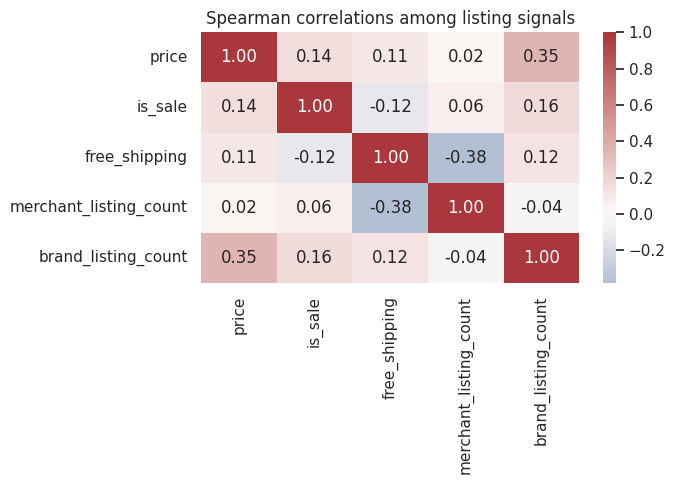

In [84]:
plt.figure(figsize=(7,5))
sns.heatmap(corr_df.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Spearman correlations among listing signals")
plt.tight_layout(); plt.show()

# Part 09 — Visualizing Distribution

## Price distribution

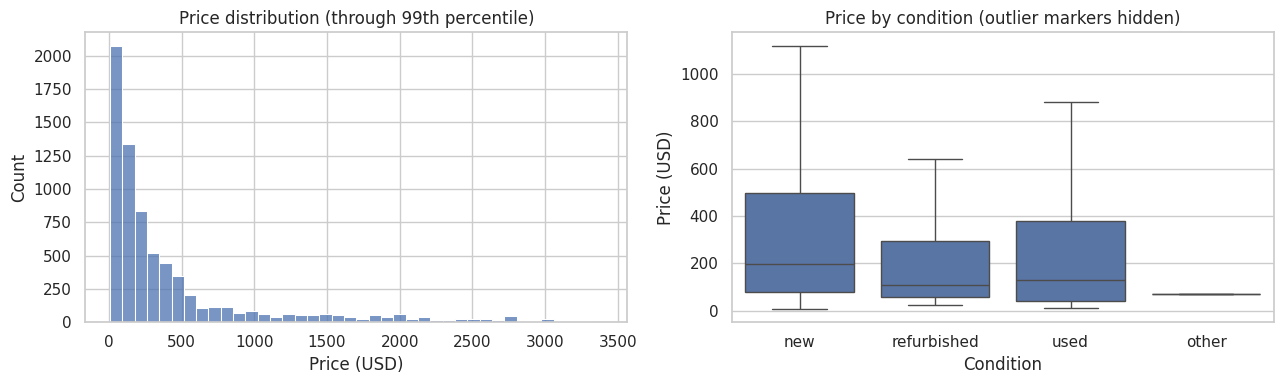

In [85]:
upper = df["price"].quantile(.99)
fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.histplot(df.loc[df.price<=upper,"price"], bins=40, ax=axes[0])
axes[0].set(title="Price distribution (through 99th percentile)", xlabel="Price (USD)")
sns.boxplot(data=df, x="condition_clean", y="price", showfliers=False, ax=axes[1])
axes[1].set(title="Price by condition (outlier markers hidden)", xlabel="Condition", ylabel="Price (USD)")
plt.tight_layout(); plt.show()

## Listing distribution by category

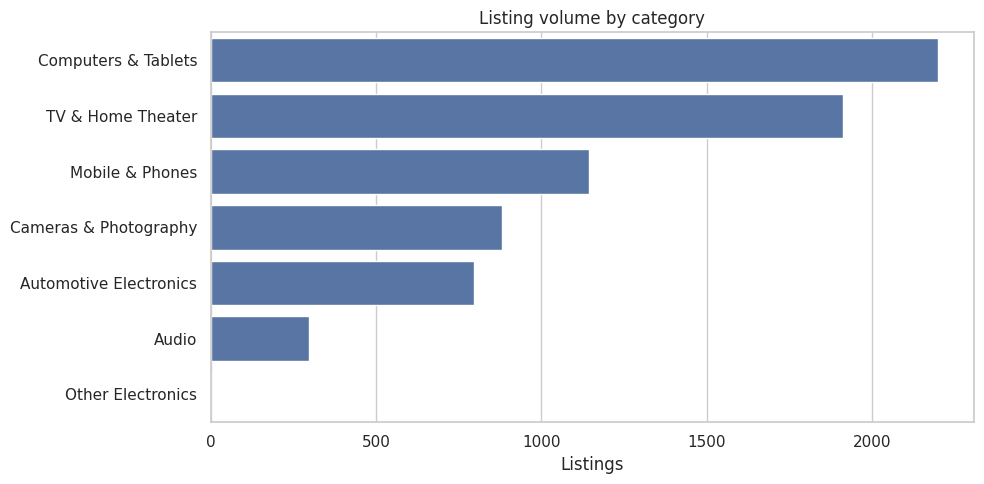

In [86]:
order=df["category_clean"].value_counts().index
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="category_clean", order=order)
plt.title("Listing volume by category"); plt.xlabel("Listings"); plt.ylabel(""); plt.tight_layout(); plt.show()

# Part 10 — Visualizing Relationship

## Brand positioning map

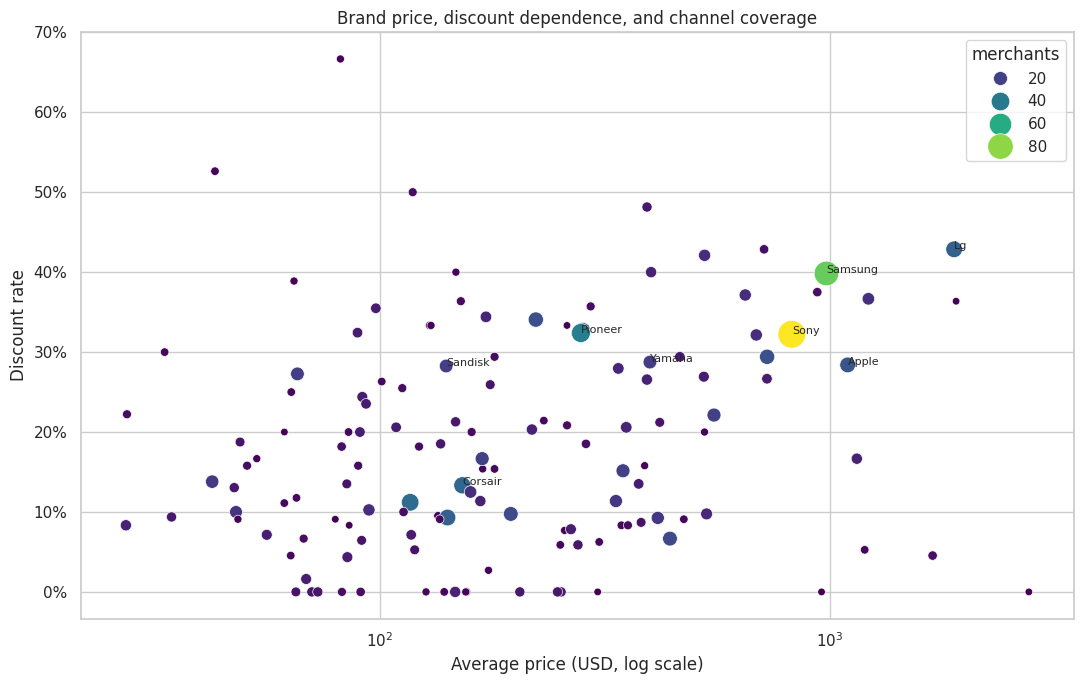

In [87]:
brand = df.groupby("brand_clean").agg(avg_price=("price","mean"), discount_rate=("sale_flag","mean"), merchants=("merchant_clean","nunique"), listings=("id","size")).query("listings >= 10").reset_index()
plt.figure(figsize=(11,7))
sns.scatterplot(data=brand, x="avg_price", y="discount_rate", size="merchants", hue="merchants", sizes=(30,400), palette="viridis")
plt.xscale("log"); plt.gca().yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
plt.title("Brand price, discount dependence, and channel coverage"); plt.xlabel("Average price (USD, log scale)"); plt.ylabel("Discount rate")
for _,r in brand.nlargest(8,"listings").iterrows(): plt.annotate(r.brand_clean,(r.avg_price,r.discount_rate),fontsize=8)
plt.tight_layout(); plt.show()

## Interpretation

Upper-right brands combine higher prices with frequent promotions; larger points have broader merchant coverage.

# Part 11 — Visualizing Composition

## Merchant composition

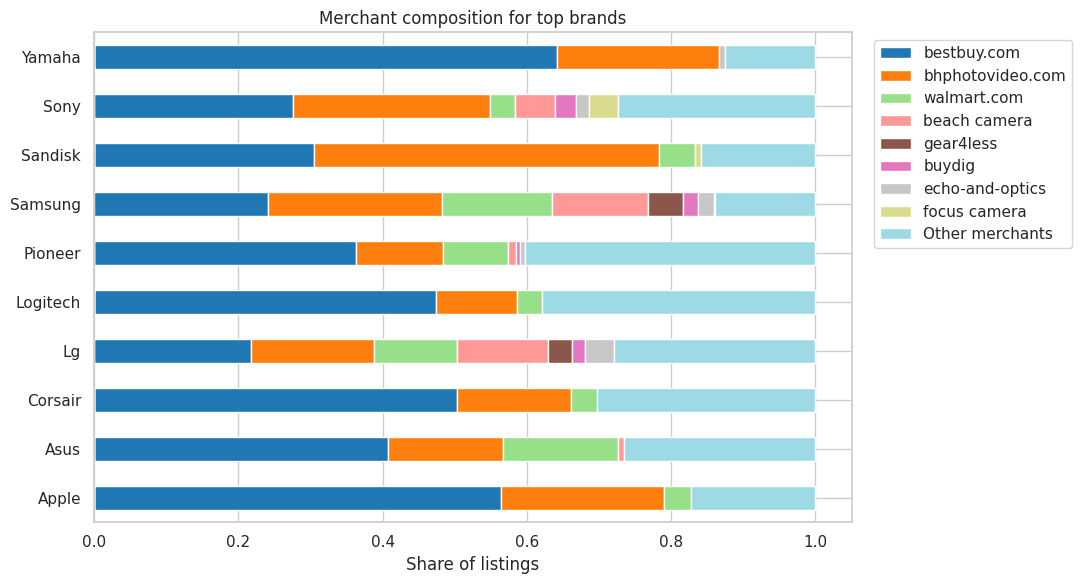

In [88]:
top_brands = df["brand_clean"].value_counts().head(10).index
mix = pd.crosstab(df.loc[df.brand_clean.isin(top_brands),"brand_clean"], df.loc[df.brand_clean.isin(top_brands),"merchant_clean"], normalize="index")
top_merchants = df.loc[df.brand_clean.isin(top_brands),"merchant_clean"].value_counts().head(8).index
plot_mix = mix.reindex(columns=top_merchants, fill_value=0)
plot_mix["Other merchants"] = 1-plot_mix.sum(axis=1)
plot_mix.plot(kind="barh", stacked=True, figsize=(11,6), colormap="tab20")
plt.title("Merchant composition for top brands"); plt.xlabel("Share of listings"); plt.ylabel(""); plt.legend(bbox_to_anchor=(1.02,1)); plt.tight_layout(); plt.show()

## Concentration KPI

In [89]:
counts=df.groupby(["brand_clean","merchant_clean"]).size().rename("n").reset_index()
conc=counts.groupby("brand_clean").agg(top_merchant_share=("n",lambda s:s.max()/s.sum()), merchants=("merchant_clean","nunique"), listings=("n","sum")).query("listings>=10").sort_values("top_merchant_share",ascending=False)
conc_display=conc.head(20).copy(); conc_display["top_merchant_share"]=conc_display["top_merchant_share"].map(lambda x:f"{x:.1%}")
display(conc_display)

,top_merchant_share,merchants,listings
brand_clean,,,
Sharkk,90.0%,2,10
Insignia,84.2%,4,19
Atrend,81.8%,2,11
Niles,81.8%,2,11
Panamax,76.9%,4,13
Spartan,76.9%,3,13
Zoom,74.1%,6,27
Audioquest,73.0%,3,37
Xfx,72.7%,4,11


# Part 12 — Visualizing Comparison

## Price index by brand and category

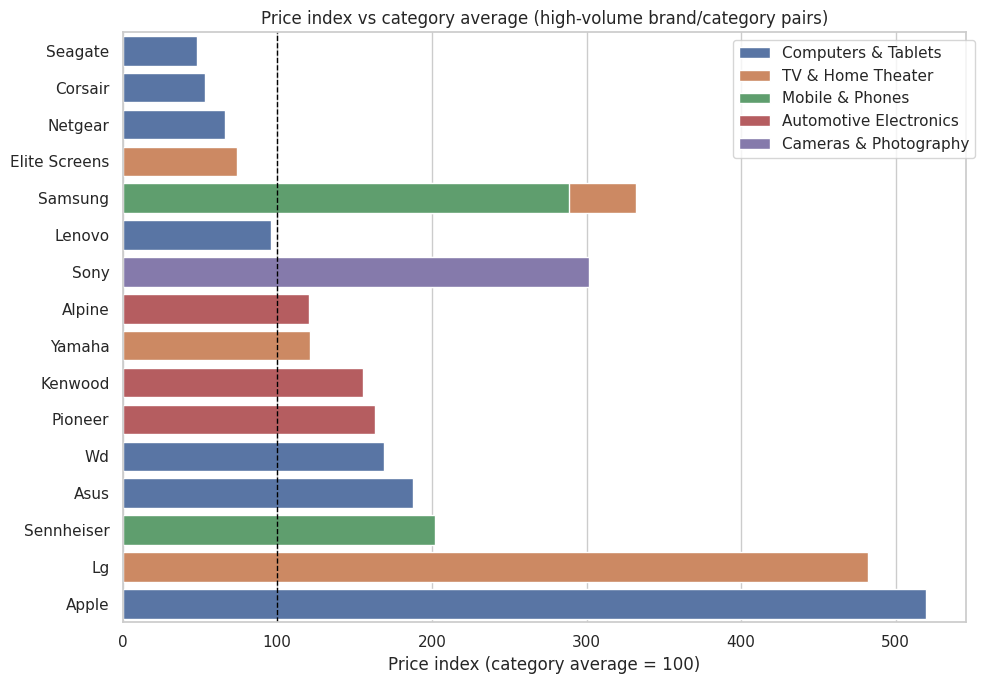

In [90]:
bc=df.groupby(["category_clean","brand_clean"]).agg(avg_price=("price","mean"), listings=("id","size")).reset_index()
bc["category_avg"]=bc.groupby("category_clean")["avg_price"].transform("mean")
bc["price_index"]=100*bc["avg_price"]/bc["category_avg"]
top=bc.query("listings>=10").nlargest(20,"listings").sort_values("price_index")
plt.figure(figsize=(10,7)); sns.barplot(data=top,y="brand_clean",x="price_index",hue="category_clean",dodge=False)
plt.axvline(100,color="black",ls="--",lw=1); plt.title("Price index vs category average (high-volume brand/category pairs)"); plt.xlabel("Price index (category average = 100)"); plt.ylabel(""); plt.legend(bbox_to_anchor=(1.02,1)); plt.tight_layout(); plt.show()

## Discount rate comparison

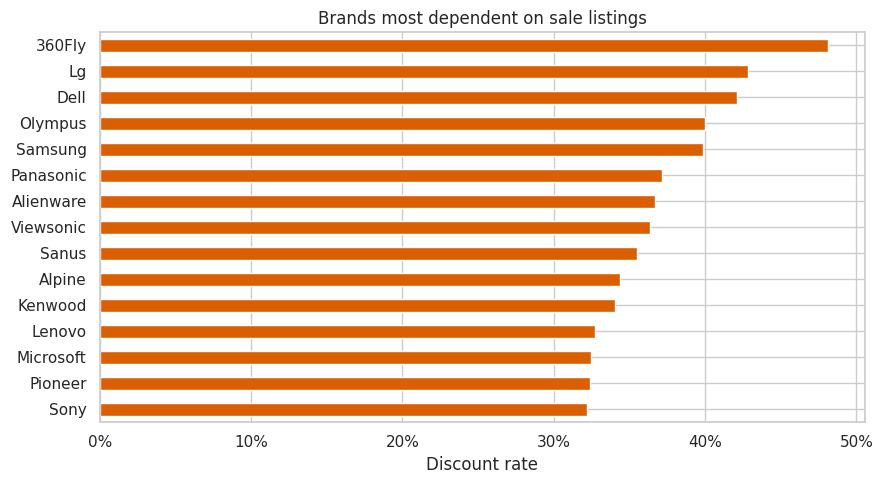

In [91]:
disc=df.groupby("brand_clean").agg(discount_rate=("sale_flag","mean"), listings=("id","size")).query("listings>=20").nlargest(15,"discount_rate").sort_values("discount_rate")
disc.discount_rate.plot.barh(figsize=(9,5),color="#d95f02"); plt.gca().xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}"); plt.title("Brands most dependent on sale listings"); plt.xlabel("Discount rate"); plt.ylabel(""); plt.tight_layout(); plt.show()

## Competition and open space

In [92]:
comp=df.groupby("category_clean").agg(brands=("brand_clean","nunique"), listings=("id","size")); comp["competition_score"]=comp.brands/comp.listings
display(comp.sort_values("competition_score",ascending=False).round(4))

,brands,listings,competition_score
category_clean,,,
Other Electronics,1,2,0.5000
Audio,36,299,0.1204
Mobile & Phones,64,1145,0.0559
Automotive Electronics,37,796,0.0465
Cameras & Photography,37,881,0.0420
Computers & Tablets,85,2199,0.0387
TV & Home Theater,57,1913,0.0298


## Used and refurbished value

In [93]:
cp=df.groupby("condition_clean")["price"].mean()
new=cp.get("new",np.nan)
value=pd.Series({"used_discount_pct":(new-cp.get("used",np.nan))/new*100,"refurbished_discount_pct":(new-cp.get("refurbished",np.nan))/new*100})
display(cp.round(2).to_frame("average_price")); display(value.round(1).to_frame("percent"))

,average_price
condition_clean,
new,487.38
other,70.68
refurbished,211.68
used,314.41


,percent
used_discount_pct,35.5
refurbished_discount_pct,56.6


# KPI Visualizations



## 1. Price positioning by brand

The price index compares each brand/category average with its category average. A value above 100 indicates above-market pricing.

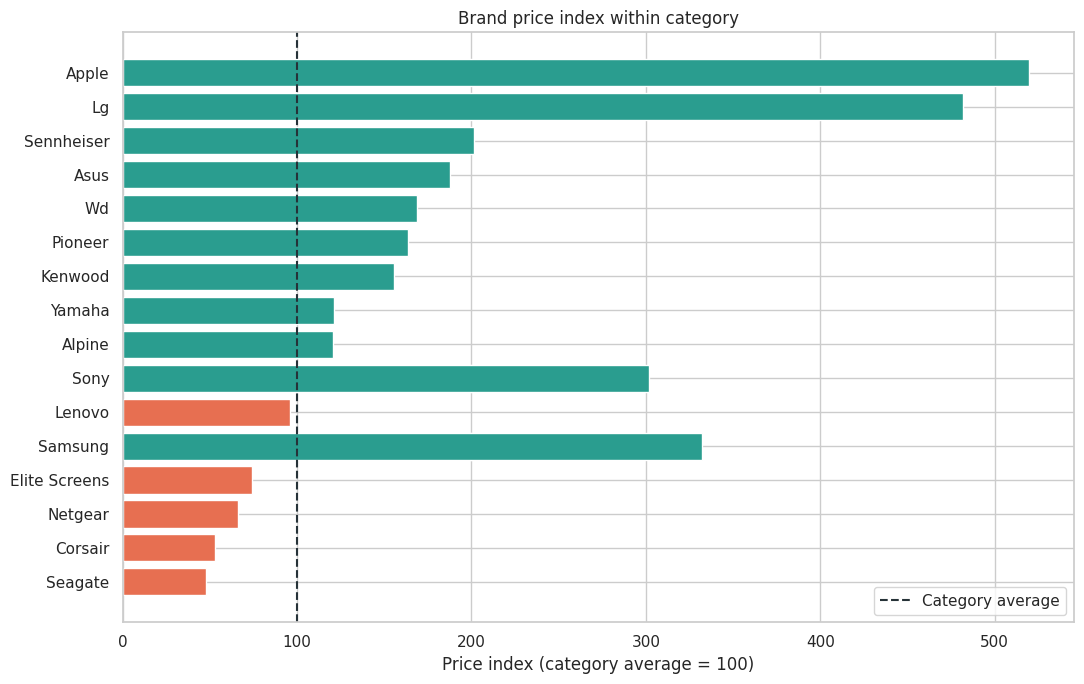

In [94]:
position = (df.groupby(["category_clean", "brand_clean"])
              .agg(avg_price=("price", "mean"), listings=("id", "size"))
              .reset_index())
position["category_avg"] = position.groupby("category_clean")["avg_price"].transform("mean")
position["price_index"] = 100 * position["avg_price"] / position["category_avg"]
position_plot = position.query("listings >= 15").nlargest(20, "listings").sort_values("price_index")

plt.figure(figsize=(11, 7))
colors = np.where(position_plot["price_index"] >= 100, "#2a9d8f", "#e76f51")
plt.barh(position_plot["brand_clean"], position_plot["price_index"], color=colors)
plt.axvline(100, color="#263238", linestyle="--", linewidth=1.5, label="Category average")
plt.title("Brand price index within category")
plt.xlabel("Price index (category average = 100)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Discount dependence by brand

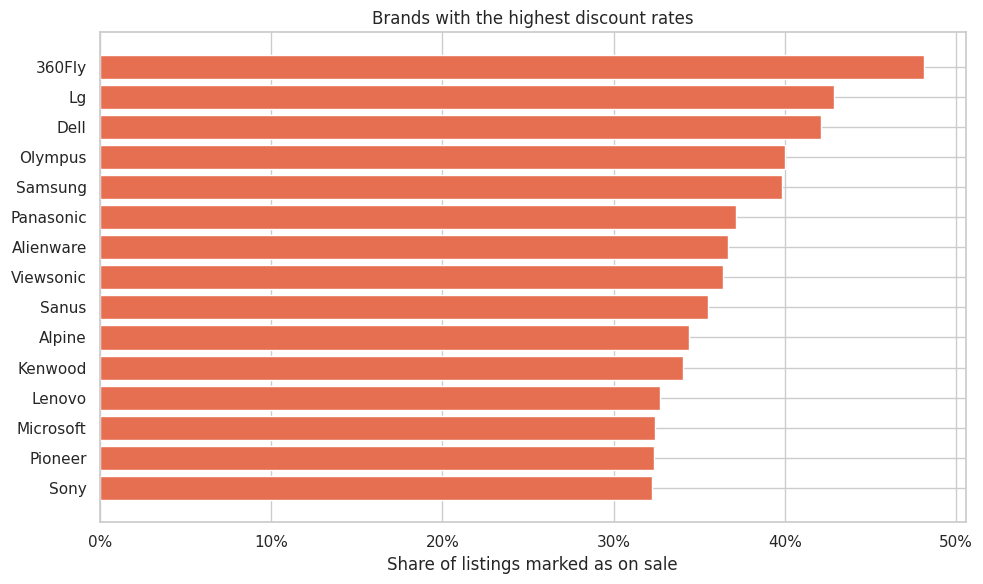

In [95]:
brand_discount = (df.groupby("brand_clean")
                    .agg(discount_rate=("sale_flag", "mean"), listings=("id", "size"))
                    .query("listings >= 20")
                    .nlargest(15, "discount_rate")
                    .sort_values("discount_rate"))

plt.figure(figsize=(10, 6))
plt.barh(brand_discount.index, brand_discount["discount_rate"], color="#e76f51")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.title("Brands with the highest discount rates")
plt.xlabel("Share of listings marked as on sale")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 3. Discount dependence by merchant

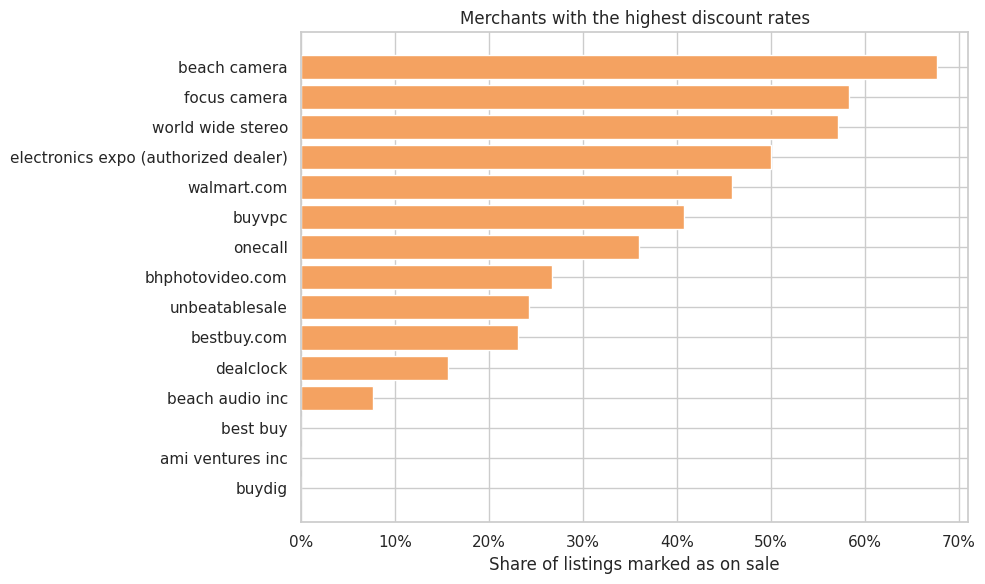

In [96]:
merchant_discount = (df.groupby("merchant_clean")
                       .agg(discount_rate=("sale_flag", "mean"), listings=("id", "size"))
                       .query("listings >= 20")
                       .nlargest(15, "discount_rate")
                       .sort_values("discount_rate"))

plt.figure(figsize=(10, 6))
plt.barh(merchant_discount.index, merchant_discount["discount_rate"], color="#f4a261")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.title("Merchants with the highest discount rates")
plt.xlabel("Share of listings marked as on sale")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Discount trend over time

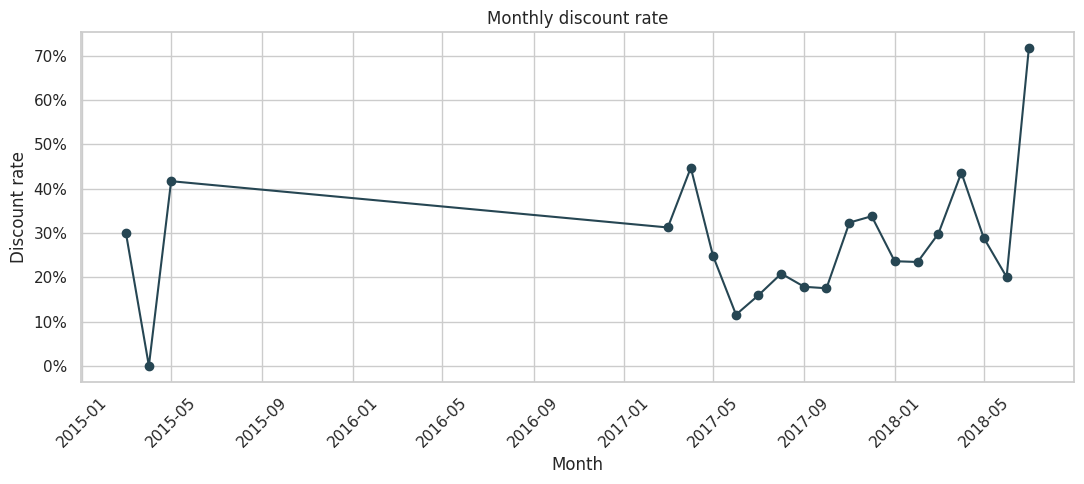

In [97]:
discount_trend = (df.dropna(subset=["date_seen"])
                    .assign(month=lambda x: x["date_seen"].dt.to_period("M").dt.to_timestamp())
                    .groupby("month")
                    .agg(discount_rate=("sale_flag", "mean"), listings=("id", "size"))
                    .query("listings >= 10"))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(discount_trend.index, discount_trend["discount_rate"], marker="o", color="#264653")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set(title="Monthly discount rate", xlabel="Month", ylabel="Discount rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Channel coverage and merchant concentration

Strong coverage is represented by more merchants; high concentration indicates greater dependence on one merchant.

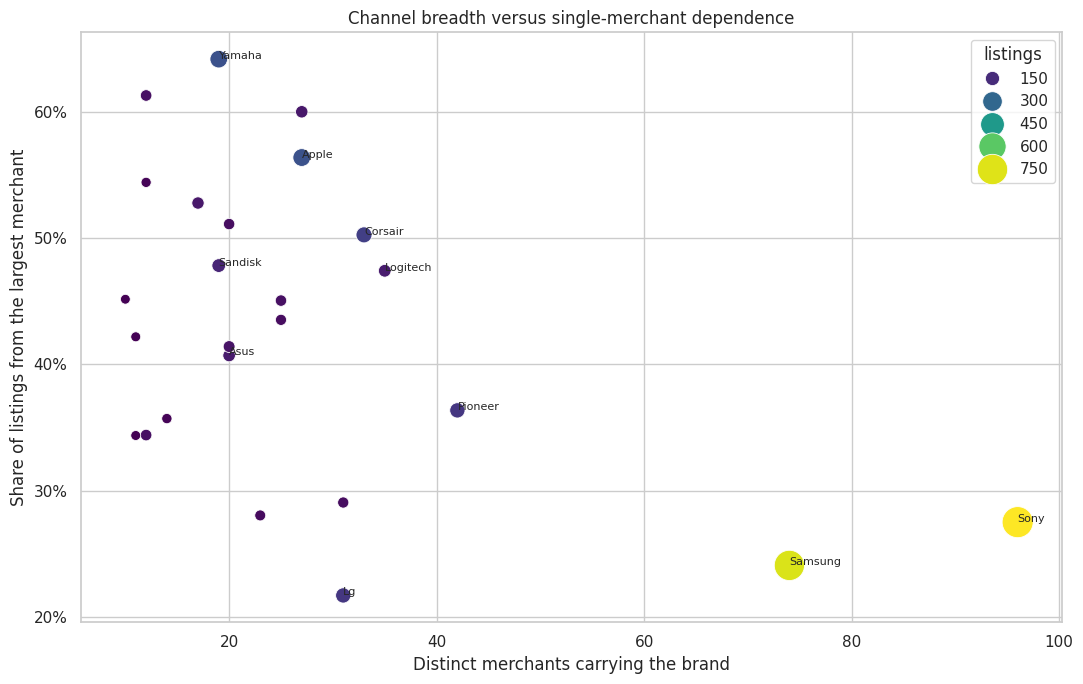

In [98]:
merchant_counts = df.groupby(["brand_clean", "merchant_clean"]).size().rename("merchant_listings").reset_index()
channel = (merchant_counts.groupby("brand_clean")
           .agg(channel_coverage=("merchant_clean", "nunique"),
                listings=("merchant_listings", "sum"),
                top_merchant_listings=("merchant_listings", "max")))
channel["top_merchant_share"] = channel["top_merchant_listings"] / channel["listings"]
channel_plot = channel.query("listings >= 20").nlargest(25, "listings").reset_index()

plt.figure(figsize=(11, 7))
sns.scatterplot(data=channel_plot, x="channel_coverage", y="top_merchant_share",
                size="listings", hue="listings", sizes=(50, 500), palette="viridis")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.title("Channel breadth versus single-merchant dependence")
plt.xlabel("Distinct merchants carrying the brand")
plt.ylabel("Share of listings from the largest merchant")
for _, row in channel_plot.nlargest(10, "listings").iterrows():
    plt.annotate(row["brand_clean"], (row["channel_coverage"], row["top_merchant_share"]), fontsize=8)
plt.tight_layout()
plt.show()

## 6. Category competition map

The bubble size represents listing volume. The score is best interpreted together with both axes rather than on its own.

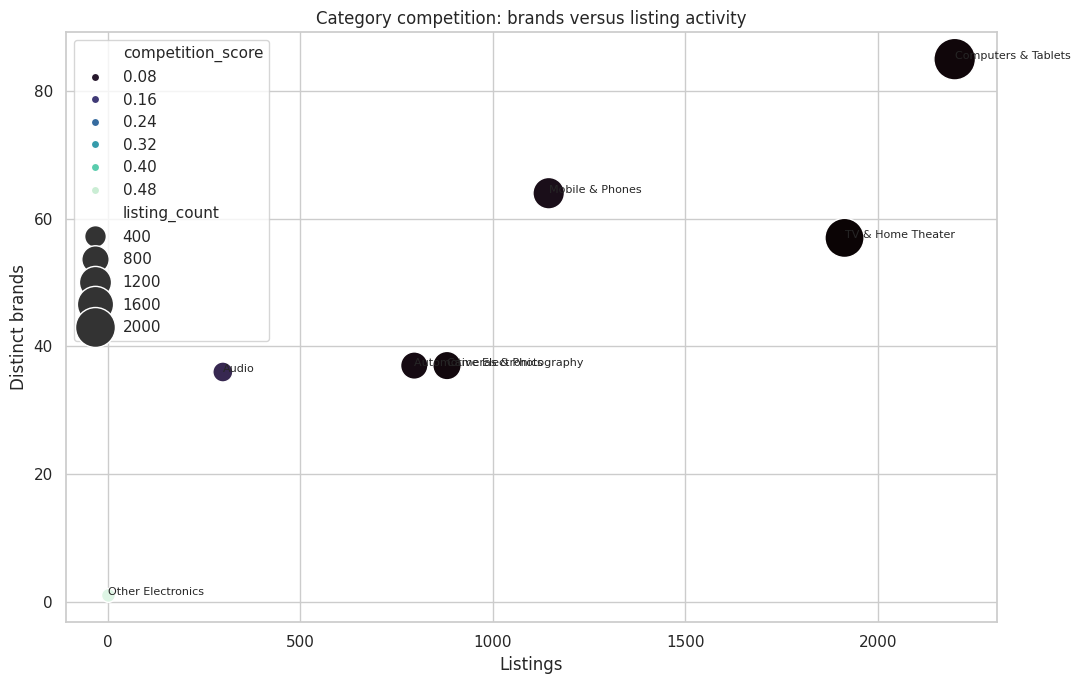

In [99]:
category_competition = (df.groupby("category_clean")
                        .agg(brand_count=("brand_clean", "nunique"),
                             listing_count=("id", "size"),
                             product_count=("id", "nunique"))
                        .reset_index())
category_competition["competition_score"] = category_competition["brand_count"] / category_competition["listing_count"]

plt.figure(figsize=(11, 7))
sns.scatterplot(data=category_competition, x="listing_count", y="brand_count",
                size="listing_count", hue="competition_score", sizes=(100, 900), palette="mako")
plt.title("Category competition: brands versus listing activity")
plt.xlabel("Listings")
plt.ylabel("Distinct brands")
for _, row in category_competition.iterrows():
    plt.annotate(row["category_clean"], (row["listing_count"], row["brand_count"]), fontsize=8)
plt.tight_layout()
plt.show()

## 7. New, used, and refurbished value

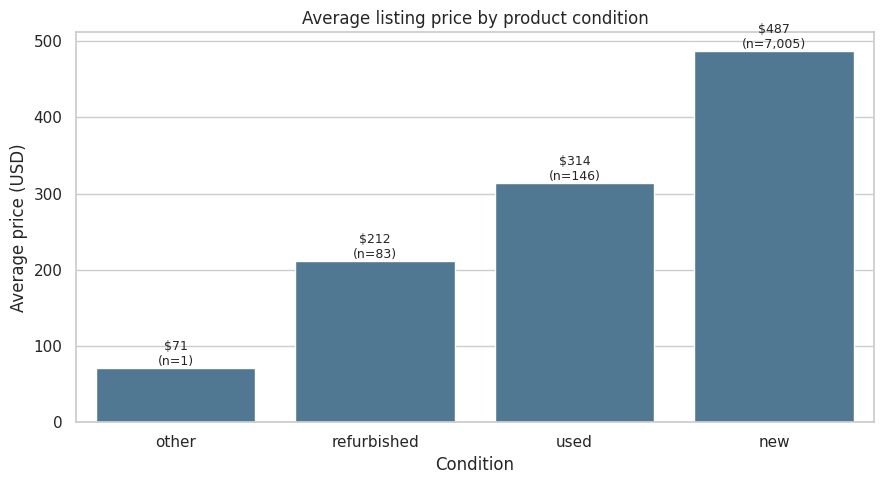

,price gap
Used discount vs new,35.5%
Refurbished discount vs new,56.6%


In [100]:
condition_summary = (df.groupby("condition_clean")
                     .agg(average_price=("price", "mean"), median_price=("price", "median"), listings=("id", "size"))
                     .reset_index()
                     .sort_values("average_price"))

plt.figure(figsize=(9, 5))
sns.barplot(data=condition_summary, x="condition_clean", y="average_price", color="#457b9d")
plt.title("Average listing price by product condition")
plt.xlabel("Condition")
plt.ylabel("Average price (USD)")
for index, row in condition_summary.reset_index(drop=True).iterrows():
    plt.text(index, row["average_price"], f'${row["average_price"]:,.0f}\n(n={row["listings"]:,})', ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

condition_prices = condition_summary.set_index("condition_clean")["average_price"]
new_price = condition_prices.get("new", np.nan)
condition_discounts = pd.Series({
    "Used discount vs new": (new_price - condition_prices.get("used", np.nan)) / new_price,
    "Refurbished discount vs new": (new_price - condition_prices.get("refurbished", np.nan)) / new_price,
}).dropna()
display(condition_discounts.map(lambda x: f"{x:.1%}").to_frame("price gap"))

## 8. Free-shipping rate by merchant

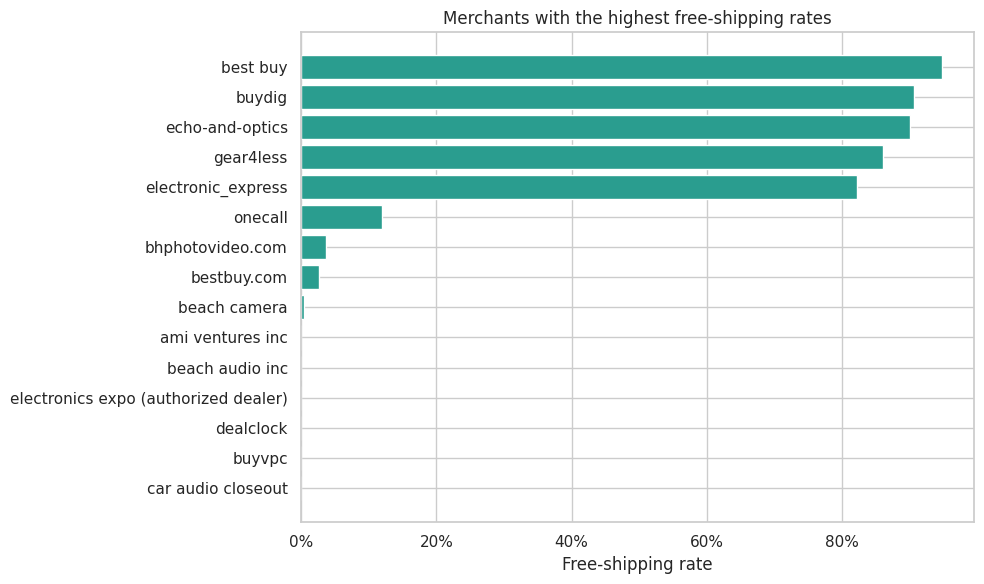

In [101]:
shipping = (df.groupby("merchant_clean")
            .agg(free_shipping_rate=("shipping_type", lambda values: values.eq("free").mean()),
                 listings=("id", "size"))
            .query("listings >= 20")
            .nlargest(15, "free_shipping_rate")
            .sort_values("free_shipping_rate"))

plt.figure(figsize=(10, 6))
plt.barh(shipping.index, shipping["free_shipping_rate"], color="#2a9d8f")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.title("Merchants with the highest free-shipping rates")
plt.xlabel("Free-shipping rate")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Findings, Explanations, and Business Implications

This section converts the calculated outputs into answers for the stakeholder. Thresholds requiring at least 15–20 listings are used in brand and merchant rankings to reduce unstable conclusions from very small samples.

## Executive KPI output

In [120]:
from IPython.display import Markdown

overall_sale_rate = df["sale_flag"].mean()
overall_free_shipping_rate = df["shipping_type"].eq("free").mean()

new_average = condition_prices.get("new", np.nan)
used_average = condition_prices.get("used", np.nan)
refurbished_average = condition_prices.get("refurbished", np.nan)
used_gap = (new_average - used_average) / new_average
refurbished_gap = (new_average - refurbished_average) / new_average

top_discount_brand = brand_discount.index[-1]
top_discount_brand_rate = brand_discount.iloc[-1]["discount_rate"]
top_discount_merchant = merchant_discount.index[-1]
top_discount_merchant_rate = merchant_discount.iloc[-1]["discount_rate"]
widest_brand = channel["channel_coverage"].idxmax()
widest_brand_merchants = int(channel.loc[widest_brand, "channel_coverage"])

reliable_competition = category_competition.query("listing_count >= 50").copy()
most_fragmented = reliable_competition.loc[reliable_competition["competition_score"].idxmax()]
most_concentrated = reliable_competition.loc[reliable_competition["competition_score"].idxmin()]

executive_kpis = pd.DataFrame({
    "KPI": [
        "Overall discount rate", "Overall free-shipping rate",
        "Highest brand discount rate (20+ listings)",
        "Highest merchant discount rate (20+ listings)",
        "Broadest brand channel coverage",
        "Used discount versus new", "Refurbished discount versus new",
        "Discount classifier ROC AUC", "Price model MAE", "Price model R²"
    ],
    "Output": [
        f"{overall_sale_rate:.1%}", f"{overall_free_shipping_rate:.1%}",
        f"{top_discount_brand}: {top_discount_brand_rate:.1%}",
        f"{top_discount_merchant}: {top_discount_merchant_rate:.1%}",
        f"{widest_brand}: {widest_brand_merchants} merchants",
        f"{used_gap:.1%}", f"{refurbished_gap:.1%}",
        f"{classifier_metrics['ROC AUC']:.3f}",
        f"${price_metrics.loc['MAE (USD)', 'Model']:,.0f}",
        f"{price_metrics.loc['R²', 'Model']:.3f}"
    ]
})
display(executive_kpis)

,KPI,Output
0,Overall discount rate,23.9%
1,Overall free-shipping rate,12.0%
2,Highest brand discount rate (20+ listings),360Fly: 48.1%
3,Highest merchant discount rate (20+ listings),beach camera: 67.7%
4,Broadest brand channel coverage,Sony: 96 merchants
5,Used discount versus new,35.5%
6,Refurbished discount versus new,56.6%
7,Discount classifier ROC AUC,0.783
8,Price model MAE,$281
9,Price model R²,0.432


## Finding 1 — Price positioning varies sharply within category

In [128]:
position_findings = (position.query("listings >= 15")
                     .sort_values("listings", ascending=False)
                     .head(20)
                     .sort_values("price_index", ascending=False)
                     [["category_clean", "brand_clean", "avg_price", "category_avg", "price_index", "listings"]])
display(position_findings.round({"avg_price": 2, "category_avg": 2, "price_index": 1}))

high_examples = position_findings.head(3)
low_examples = position_findings.tail(3).sort_values("price_index")


,category_clean,brand_clean,avg_price,category_avg,price_index,listings
115,Computers & Tablets,Apple,1529.71,294.45,519.5,164
282,TV & Home Theater,Lg,2060.61,427.40,482.1,160
298,TV & Home Theater,Samsung,1418.72,427.40,331.9,451
103,Cameras & Photography,Sony,727.66,241.16,301.7,223
306,TV & Home Theater,Sony,1244.64,427.40,291.2,332
242,Mobile & Phones,Samsung,496.80,171.99,288.9,93
244,Mobile & Phones,Sennheiser,346.96,171.99,201.7,99
117,Computers & Tablets,Asus,552.60,294.45,187.7,113
189,Computers & Tablets,Wd,497.29,294.45,168.9,87
60,Automotive Electronics,Pioneer,233.26,142.66,163.5,105


Explanation. A price index of 100 equals the category average. Values above 100 indicate above-market positioning; values below 100 indicate value positioning. In the high-volume examples, Apple in Computers & Tablets has an index of 520, while Seagate in Computers & Tablets has an index of 48.

Business implication. Compare the index with the brand promise. A premium claim paired with an index below 100 signals a positioning mismatch; a value claim paired with a very high index may require stronger feature, quality, or service justification. Category mix average prices may be reviewed alongside listing-weighted results.

## Finding 2 — Discount dependence is concentrated among specific brands and merchants

In [130]:
discount_output = (df.groupby("brand_clean")
                   .agg(discount_rate=("sale_flag", "mean"), listings=("id", "size"))
                   .query("listings >= 20")
                   .nlargest(10, "discount_rate"))
discount_output["discount_rate"] = discount_output["discount_rate"].map(lambda x: f"{x:.1%}")
display(discount_output)



,discount_rate,listings
brand_clean,,
360Fly,48.1%,27
Lg,42.9%,175
Dell,42.1%,57
Olympus,40.0%,45
Samsung,39.8%,743
Panasonic,37.1%,70
Alienware,36.7%,60
Viewsonic,36.4%,22
Sanus,35.5%,31


Explanation. 360Fly has the highest qualifying brand discount rate at 48.1%. At merchant level, beach camera is highest at 67.7%. The dataset-wide rate is 23.9%.

Business implication. Rates substantially above the dataset average identify brands or merchants whose offers rely more heavily on sale messaging. This can attract price-sensitive demand, but persistent promotion may train customers to wait for discounts. Listing volume should be checked before acting on any rank.

## Finding 3 — Discounting changes over time, but some months have limited coverage

In [131]:
trend_output = discount_trend.reset_index().copy()
trend_output["discount_rate"] = trend_output["discount_rate"].map(lambda x: f"{x:.1%}")
display(trend_output.tail(12))

peak_month = discount_trend["discount_rate"].idxmax()
peak_rate = discount_trend.loc[peak_month, "discount_rate"]
peak_listings = int(discount_trend.loc[peak_month, "listings"])


,month,discount_rate,listings
8,2017-08-01,20.8%,1038
9,2017-09-01,17.8%,611
10,2017-10-01,17.5%,891
11,2017-11-01,32.3%,365
12,2017-12-01,33.8%,465
13,2018-01-01,23.6%,432
14,2018-02-01,23.4%,64
15,2018-03-01,29.8%,305
16,2018-04-01,43.6%,117
17,2018-05-01,28.9%,826


Explanation: The highest displayed monthly discount rate is 71.7% in July 2018, based on 60 listings.

Business implication: The time series can guide campaign timing, but it should not be treated as a stable market trend because monthly listing coverage changes substantially. Compare equal-coverage periods and refresh the data before making current promotional decisions.italicised text

## Finding 4 — Channel strength combines breadth with concentration risk

In [132]:
channel_output = (channel.query("listings >= 20")
                  .sort_values(["channel_coverage", "listings"], ascending=False)
                  .head(12)
                  [["channel_coverage", "top_merchant_share", "listings"]]
                  .copy())
channel_output["top_merchant_share"] = channel_output["top_merchant_share"].map(lambda x: f"{x:.1%}")
display(channel_output)



,channel_coverage,top_merchant_share,listings
brand_clean,,,
Sony,96,27.5%,785
Samsung,74,24.1%,743
Pioneer,42,36.4%,176
Logitech,35,47.4%,116
Corsair,33,50.3%,195
Lg,31,21.7%,175
Seagate,31,29.1%,86
Apple,27,56.4%,243
Lenovo,27,60.0%,110


Explanation: Sony has the broadest observed distribution at 96 merchants. The top-merchant share shows whether that apparent breadth still depends heavily on one seller.

Business implication: Prioritize competitor merchants missing from the focal brand's network, but distinguish true distribution gaps from incomplete collection. Brands with high concentration should consider channel diversification.

## Finding 5 — Category competition reflects fragmentation, not attractiveness by itself

In [127]:
competition_output = reliable_competition.sort_values("competition_score", ascending=False).copy()
display(competition_output.round({"competition_score": 4}))



,category_clean,brand_count,listing_count,product_count,competition_score
0,Audio,36,299,58,0.1204
4,Mobile & Phones,64,1145,157,0.0559
1,Automotive Electronics,37,796,92,0.0465
2,Cameras & Photography,37,881,87,0.0420
3,Computers & Tablets,85,2199,236,0.0387
6,TV & Home Theater,57,1913,204,0.0298


Explanation: Among categories with at least 50 listings, Audio has the highest brands-per-listing score (0.120), while TV & Home Theater has the lowest (0.030). A higher score indicates greater fragmentation; a lower score indicates more listings per brand.

Business implication: Fragmented categories may provide more differentiation possibilities, while concentrated categories may be dominated by fewer brands. The score does not measure demand, profitability, or media cost, so those factors are required before selecting a category for investment.

## Finding 6 — Used and refurbished offers provide meaningful headline savings

In [133]:
condition_output = condition_summary.copy()
condition_output["average_price"] = condition_output["average_price"].map(lambda x: f"${x:,.2f}")
condition_output["median_price"] = condition_output["median_price"].map(lambda x: f"${x:,.2f}")
display(condition_output)



,condition_clean,average_price,median_price,listings
1,other,$70.68,$70.68,1
2,refurbished,$211.68,$107.99,83
3,used,$314.41,$129.97,146
0,new,$487.38,$198.00,7005


Explanation: Average used pricing is 35.5% below new, and refurbished pricing is 56.6% below new. The condition groups contain very different listing counts and may include different category and product mixes.

Business implication: These gaps support trade-in and certified-refurbished value messaging, but they are not like-for-like product matches. Products should be paired by category, brand, and product specification before advertising a precise savings claim.

## Finding 7 — Free shipping is a separate value lever

In [134]:
shipping_output = shipping.sort_values("free_shipping_rate", ascending=False).head(10).copy()
shipping_output["free_shipping_rate"] = shipping_output["free_shipping_rate"].map(lambda x: f"{x:.1%}")
display(shipping_output)



,free_shipping_rate,listings
merchant_clean,,
best buy,94.7%,38
buydig,90.6%,53
echo-and-optics,90.0%,40
gear4less,86.0%,43
electronic_express,82.1%,28
onecall,12.0%,25
bhphotovideo.com,3.6%,1509
bestbuy.com,2.6%,2794
beach camera,0.5%,201


Explanation: Free shipping appears on 12.0% of all listings, but usage differs considerably by merchant.

Business implication: A merchant can compete on convenience even without the lowest price. Include shipping in offer evaluation rather than interpreting sticker price alone.